# Computer Vision Mini Project

#### - Name: Jasser Abdelfattah

#### - UH ID: 21033101


## Loading CIFAR-10 and Data Preprocessing

### Environment Setup

- **PyTorch Version**: To install PyTorch along with torchvision and torchaudio, use the following command:
  ```sh
  pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
  ```

- **Python Version**: 3.10.15
- **Dependencies**: All required packages are listed in `requirements.txt`.


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from PIL import Image
import numpy as np
import cv2

In [2]:
# Number of epochs to train the model
num_epochs = 157

# Batch size for training
batch_size = 128

# Learning rate for the optimizer
learning_rate = 0.009739054477909789

In [3]:
def histogram_equalization(image):
    """
    Apply histogram equalization to the input image to improve its contrast.

    Parameters:
    image (numpy.ndarray): Input image in RGB format.

    Returns:
    numpy.ndarray: Image with equalized histogram in RGB format.
    """
    img_y_cr_cb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_y_cr_cb)
    y_eq = cv2.equalizeHist(y)
    img_y_cr_cb_eq = cv2.merge((y_eq, cr, cb))
    img_rgb_eq = cv2.cvtColor(img_y_cr_cb_eq, cv2.COLOR_YCrCb2RGB)
    return img_rgb_eq

In [4]:
class CIFAR10WithHE(CIFAR10):
    """
    CIFAR10WithHE is a subclass of the CIFAR10 dataset that applies histogram equalization to each image.

    Methods
    -------
    __getitem__(index)
        Retrieves the image and target at the specified index, applies histogram equalization to the image,
        and then applies any additional transformations if specified.

    Parameters
    ----------
    index : int
        The index of the image and target to retrieve.

    Returns
    -------
    tuple
        A tuple containing the transformed image and its corresponding target.
    """

    def __getitem__(self, index):
        img, target = self.data[index], self.targets[index]
        img = Image.fromarray(img)
        img = np.array(img)
        img = histogram_equalization(img)
        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, target


# Define a transform to normalize the data
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

# Load the training dataset with histogram equalization
train_dataset = CIFAR10WithHE(
    root="./CIFAR10_data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)

# Load the test dataset with histogram equalization
test_dataset = CIFAR10WithHE(
    root="./CIFAR10_data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)


# Define the classes in the CIFAR-10 dataset
classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
    )

100%|██████████| 170M/170M [00:03<00:00, 46.2MB/s]


Extracting ./CIFAR10_data/cifar-10-python.tar.gz to ./CIFAR10_data
Files already downloaded and verified


In [5]:
import matplotlib.pyplot as plt

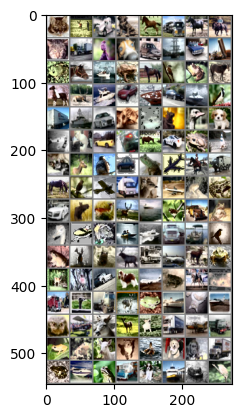

cat deer truck dog


In [6]:
# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Show images
imshow(torchvision.utils.make_grid(images))

# Print labels
print(" ".join(f"{classes[labels[j]]}" for j in range(4)))

## Building The Object Recognition Model Using Convolutional Neural Network Architecture


In [7]:
import torch.nn as nn
import torch.nn.functional as F

In [8]:
# Define a Convolutional Neural Network (CNN) class
class CCN(nn.Module):
    def __init__(self):
        super(CCN, self).__init__()
        # First convolutional layer: 3 input channels (RGB), 16 output channels, 3x3 kernel, stride 1, padding 1
        self.conv1 = nn.Conv2d(3, 16, 3, 1, padding=1)
        # Second convolutional layer: 16 input channels, 32 output channels, 3x3 kernel, stride 1, padding 1
        self.conv2 = nn.Conv2d(16, 32, 3, 1, padding=1)
        # Third convolutional layer: 32 input channels, 64 output channels, 3x3 kernel, stride 1, padding 1
        self.conv3 = nn.Conv2d(32, 64, 3, 1, padding=1)
        # Fully connected layer: input size 4*4*64, output size 500
        self.fc1 = nn.Linear(4 * 4 * 64, 500)
        # Dropout layer with a dropout probability of 0.2
        self.dropout = nn.Dropout(0.2)
        # Fully connected layer: input size 500, output size 10 (number of classes)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        # Apply first convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        # Apply second convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        # Apply third convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)
        # Flatten the tensor for the fully connected layer
        x = x.view(-1, 4 * 4 * 64)
        # Apply first fully connected layer followed by ReLU activation
        x = F.relu(self.fc1(x))
        # Apply dropout
        x = self.dropout(x)
        # Apply second fully connected layer
        x = self.fc2(x)
        return x


# Check if GPU is available and set the device accordingly
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate the model and move it to the appropriate device
model = CCN().to(device)
model

CCN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=500, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

## Training the CNN (Convolutional Neural Network) Model


In [9]:
import torch.optim as optim

In [10]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

In [11]:
running_loss_history = []
running_corrects_history = []
test_running_loss_history = []
test_running_corrects_history = []

# Loop over the number of epochs
for e in range(num_epochs):
    running_loss = 0.0
    running_corrects = 0.0
    test_running_loss = 0.0
    test_running_corrects = 0.0

    # Training phase
    for inputs, labels in train_loader:
        inputs = inputs.to(device)  # Move inputs to the device (GPU or CPU)
        labels = labels.to(device)  # Move labels to the device (GPU or CPU)
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss

        optimizer.zero_grad()  # Zero the gradients
        loss.backward()  # Backward pass
        optimizer.step()  # Update the weights

        _, preds = torch.max(outputs, 1)  # Get the predictions
        running_loss += loss.item()  # Accumulate the loss
        running_corrects += torch.sum(
            preds == labels.data
        )  # Accumulate the correct predictions

    # Testing phase
    else:
        with torch.no_grad():  # Disable gradient calculation
            for test_inputs, test_labels in test_loader:
                test_inputs = test_inputs.to(device)  # Move test inputs to the device
                test_labels = test_labels.to(device)  # Move test labels to the device
                test_outputs = model(test_inputs)  # Forward pass
                test_loss = criterion(
                    test_outputs, test_labels
                )  # Compute the test loss

                _, test_preds = torch.max(test_outputs, 1)  # Get the test predictions
                test_running_loss += test_loss.item()  # Accumulate the test loss
                test_running_corrects += torch.sum(
                    test_preds == test_labels.data
                )  # Accumulate the correct test predictions

        # Compute the average training loss and accuracy for the epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = running_corrects.float() / len(train_loader)
        running_loss_history.append(epoch_loss)  # Store the training loss
        running_corrects_history.append(epoch_acc)  # Store the training accuracy

        # Compute the average testing loss and accuracy for the epoch
        test_epoch_loss = test_running_loss / len(test_loader)
        test_epoch_acc = test_running_corrects.float() / len(test_loader)
        test_running_loss_history.append(test_epoch_loss)  # Store the test loss
        test_running_corrects_history.append(test_epoch_acc)  # Store the test accuracy

        # Print the training and testing loss and accuracy for the epoch
        print(f'epoch: {e + 1}')
        print(f'training loss: {epoch_loss:.4f}, acc {epoch_acc:.4f}')
        print(f'testing loss: {test_epoch_loss:.4f}, acc {test_epoch_acc:.4f}')



epoch: 1
training loss: 1.9744, acc 35.3095
testing loss: 1.6276, acc 51.7089
epoch: 2
training loss: 1.4832, acc 59.3836
testing loss: 1.3501, acc 64.5949
epoch: 3
training loss: 1.2388, acc 71.4271
testing loss: 1.1702, acc 74.4177
epoch: 4
training loss: 1.0639, acc 79.9616
testing loss: 1.1236, acc 77.2279
epoch: 5
training loss: 0.9506, acc 85.1816
testing loss: 0.9991, acc 83.2279
epoch: 6
training loss: 0.8547, acc 89.7877
testing loss: 0.9361, acc 85.3418
epoch: 7
training loss: 0.7843, acc 92.8338
testing loss: 0.8954, acc 87.3544
epoch: 8
training loss: 0.7037, acc 96.3120
testing loss: 0.8973, acc 87.7215
epoch: 9
training loss: 0.6408, acc 99.1330
testing loss: 0.8856, acc 89.0506
epoch: 10
training loss: 0.5790, acc 101.9514
testing loss: 0.8796, acc 88.2785
epoch: 11
training loss: 0.5194, acc 104.3581
testing loss: 0.9015, acc 89.3418
epoch: 12
training loss: 0.4566, acc 107.2276
testing loss: 0.9278, acc 89.3291
epoch: 13
training loss: 0.4011, acc 109.8465
testing loss

## Evaluating the Object Recognition Model


In [12]:
# Compute the average training loss and accuracy for the epoch
epoch_loss = running_loss / len(train_loader.dataset)
epoch_acc = running_corrects.float() / len(train_loader.dataset)
running_loss_history.append(epoch_loss)  # Store the training loss
running_corrects_history.append(epoch_acc)  # Store the training accuracy

# Compute the average testing loss and accuracy for the epoch
test_epoch_loss = test_running_loss / len(test_loader.dataset)
test_epoch_acc = test_running_corrects.float() / len(test_loader.dataset)
test_running_loss_history.append(test_epoch_loss)  # Store the test loss
test_running_corrects_history.append(test_epoch_acc)  # Store the test accuracy

# Print the final training and testing accuracy in percentage
final_train_acc = running_corrects_history[-1].item() * 100
final_test_acc = test_running_corrects_history[-1].item() * 100
print(f"Final Training Accuracy: {final_train_acc:.2f}%")
print(f"Final Testing Accuracy: {final_test_acc:.2f}%")

Final Training Accuracy: 99.47%
Final Testing Accuracy: 69.59%


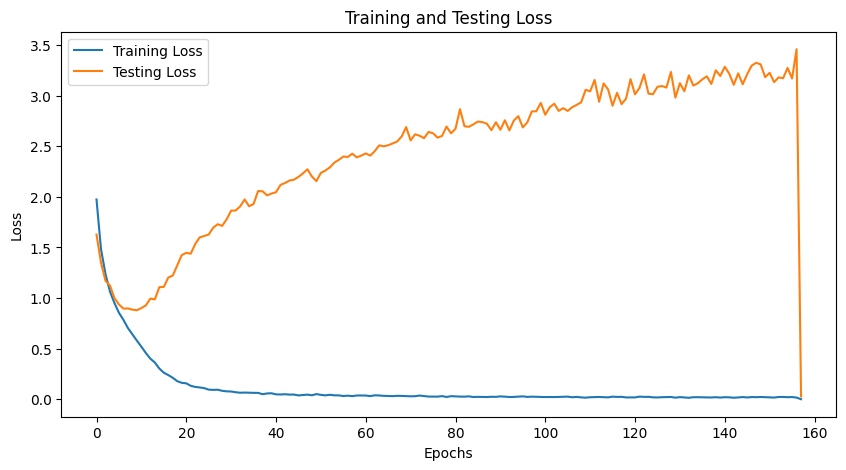

In [13]:
# Plot the training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(running_loss_history, label="Training Loss")
plt.plot(test_running_loss_history, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Testing Loss")
plt.show()

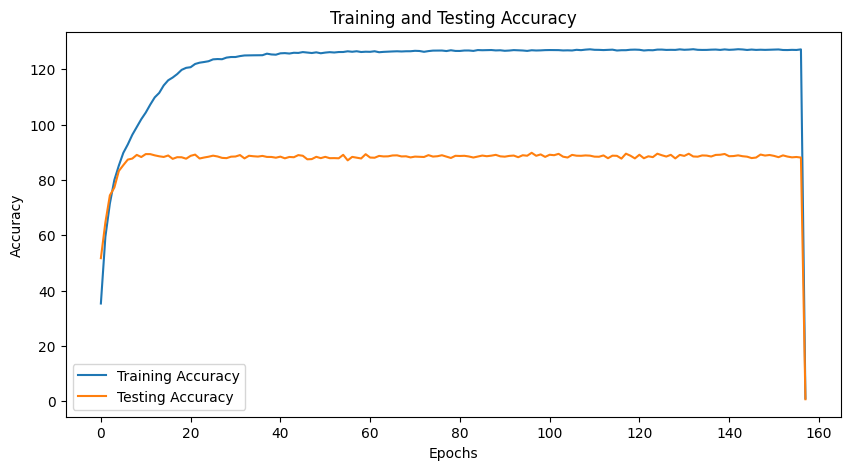

In [14]:
# Plot the training and testing accuracy
plt.figure(figsize=(10, 5))
plt.plot(
    [acc.cpu().numpy() for acc in running_corrects_history], label="Training Accuracy"
)
plt.plot(
    [acc.cpu().numpy() for acc in test_running_corrects_history],
    label="Testing Accuracy",
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Testing Accuracy")
plt.show()

## Saving The Model


In [15]:
PATH = "./cifar10_Net.pth"
torch.save(model.state_dict(), PATH)

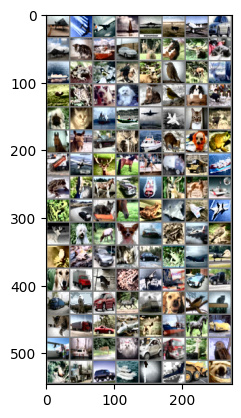

GroundTruth:  plane plane plane  ship


In [16]:
# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Display the images in a grid format
imshow(torchvision.utils.make_grid(images))

# Print the ground truth labels for the images
print("GroundTruth: ", " ".join("%5s" % classes[labels[j]] for j in range(4)))

## Predictions on Test Images


In [17]:
net = CCN()
net.load_state_dict(torch.load(PATH))

<ipython-input-17-4a90921a81a6>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [18]:
outputs = net(images)

In [19]:
outputs.shape

torch.Size([128, 10])

In [20]:
# Initialize variables to track the overall correct predictions and total samples
correct = 0
total = 0

# Initialize lists to track the correct predictions and total samples for each class
class_correct = list(0.0 for i in range(10))
class_total = list(0.0 for i in range(10))

# Disable gradient calculation for evaluation
with torch.no_grad():
    for data in test_loader:
        images, labels = data  # Get the images and labels from the test loader
        outputs = net(images)  # Forward pass: compute the outputs of the network
        _, predicted = torch.max(
            outputs, 1
        )  # Get the predicted class with the highest score
        c = (predicted == labels).squeeze()  # Compare predictions with the true labels

        # Update the correct predictions and total samples for each class
        for i in range(len(labels)):
            label = labels[i]  # Get the true label
            class_correct[label] += c[
                i
            ].item()  # Increment the correct count for the class
            class_total[label] += 1  # Increment the total count for the class

    # Print the accuracy for each class
    for i in range(len(classes)):
        if class_total[i] > 0:
            print(
                "Accuracy of %5s : %2d %%"
                % (classes[i], 100 * class_correct[i] / class_total[i])
            )

    # Calculate and print the overall accuracy of the network
    overall_accuracy = 100.0 * sum(class_correct) / sum(class_total)
    print("Accuracy of the network on the 10000 test images: %d %%" % overall_accuracy)

Accuracy of plane : 75 %
Accuracy of   car : 79 %
Accuracy of  bird : 55 %
Accuracy of   cat : 47 %
Accuracy of  deer : 67 %
Accuracy of   dog : 57 %
Accuracy of  frog : 81 %
Accuracy of horse : 66 %
Accuracy of  ship : 86 %
Accuracy of truck : 81 %
Accuracy of the network on the 10000 test images: 69 %


## Prediction of Unseen Images


In [21]:
# Function to predict the class of a single image
def predict_single_image(model, image_path, classes, device):
    # Define the image transformations (resize, normalize, etc.)
    transform = transforms.Compose(
        [
            transforms.Resize(
                (32, 32)
            ),  # Resize the image to the input size expected by the model
            transforms.ToTensor(),  # Convert the image to a tensor
            transforms.Normalize(
                (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
            ),  # Normalize the image
        ]
    )

    # Load the image
    image = Image.open(image_path)
    image = transform(image).unsqueeze(
        0
    )  # Apply transformations and add batch dimension

    # Move the image to the device (GPU or CPU)
    image = image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Disable gradient calculation
    with torch.no_grad():
        # Forward pass: compute the outputs of the network
        outputs = model(image)
        # Get the predicted class with the highest score
        _, predicted = torch.max(outputs, 1)

    # Get the predicted class label
    predicted_class = classes[predicted.item()]

    # Display the image along with the predicted label
    image = (
        image.cpu().squeeze().permute(1, 2, 0).numpy()
    )  # Move image back to CPU and convert to numpy array
    image = image * 0.5 + 0.5  # Unnormalize the image
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}")
    plt.show()


# Example usage
image_path = "airplane2.png"
classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

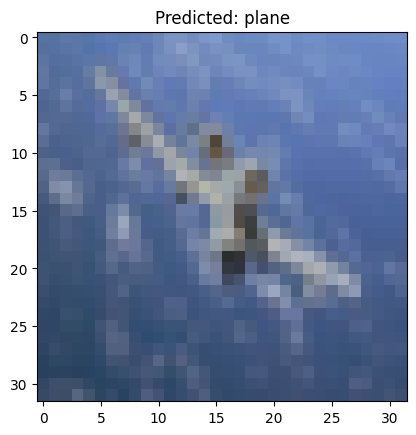

In [22]:
predict_single_image(model, image_path, classes, device)